### EDA for Sales Quantity - SARIMA

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#Load Dataset
df=pd.read_csv("../data/Coffee Shop Sales.csv")

In [ ]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
# Convert transaction_date to datetime for time series analysis
df["transaction_date"] = pd.to_datetime(df["transaction_date"], format="%d-%m-%Y", errors="coerce")

In [ ]:
df["transaction_price"]=df["transaction_qty"]*df["unit_price"]

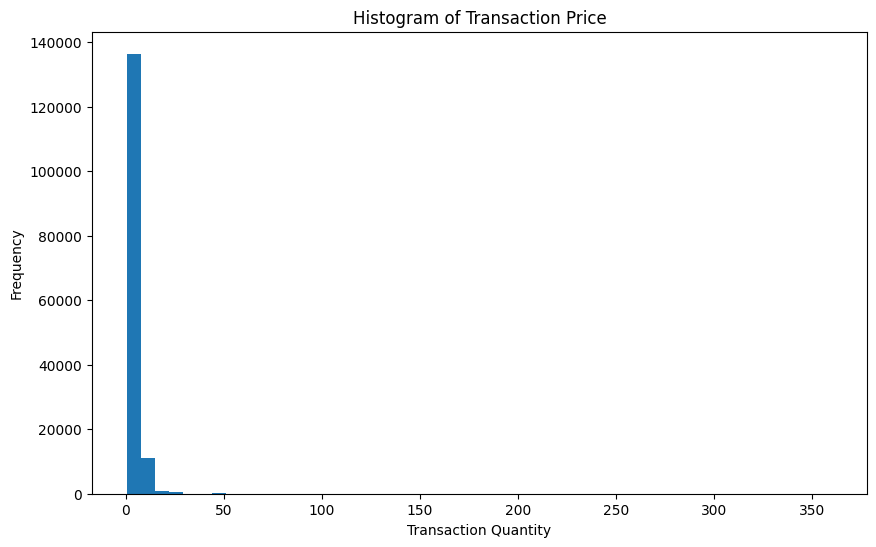

In [ ]:
df.hist(column="transaction_price", bins=50, figsize=(10, 6))
plt.xlabel("Transaction Quantity")
plt.ylabel("Frequency")
plt.title("Histogram of Transaction Price")
plt.grid()

In [ ]:
# Aggregate total quantity sold per day per category
df_perday = df.groupby(["transaction_date"])["transaction_qty"].sum().reset_index()

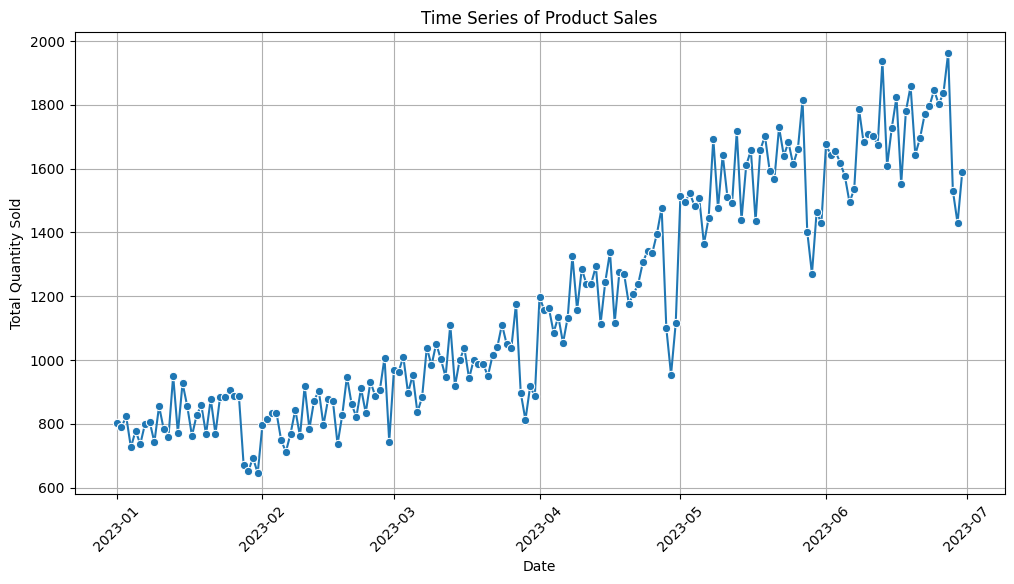

In [ ]:
# Plot time series using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_perday, x="transaction_date", y="transaction_qty", marker="o")

# Formatting
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.title("Time Series of Product Sales")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
plt.rc('figure', figsize=(14, 8)) 
plt.rc('font', size=15)


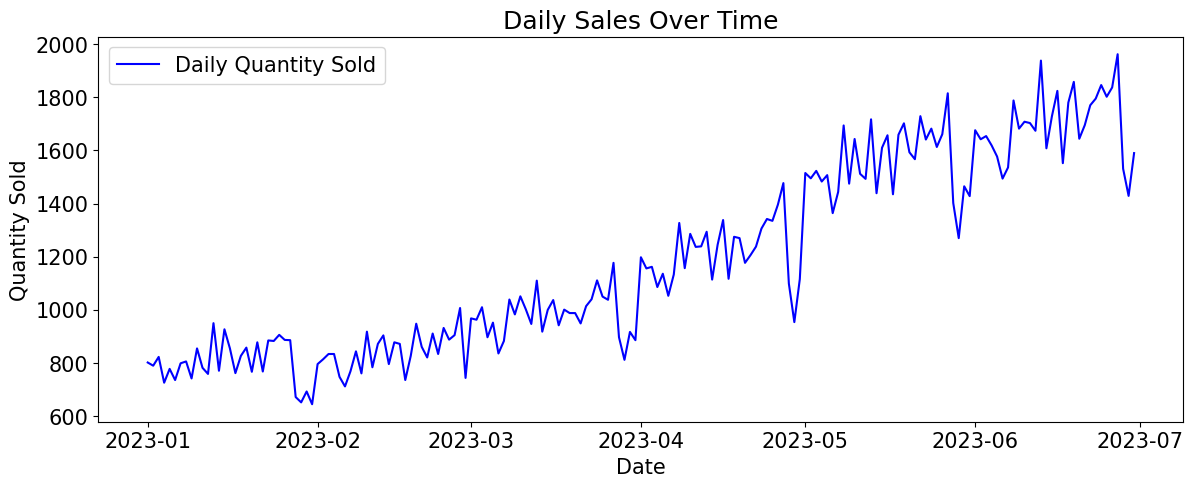

In [ ]:
# Ensure the date column is in datetime format
df_perday["transaction_date"] = pd.to_datetime(df_perday["transaction_date"])
df_perday.set_index("transaction_date", inplace=True)
df_perday = df_perday.asfreq("D")  # Ensure daily frequency
df_perday.sort_index(inplace=True)

# Plot the time series
plt.figure(figsize=(14,5))
plt.plot(df_perday["transaction_qty"], label="Daily Quantity Sold", color="blue")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.title("Daily Sales Over Time")
plt.legend()
plt.show()


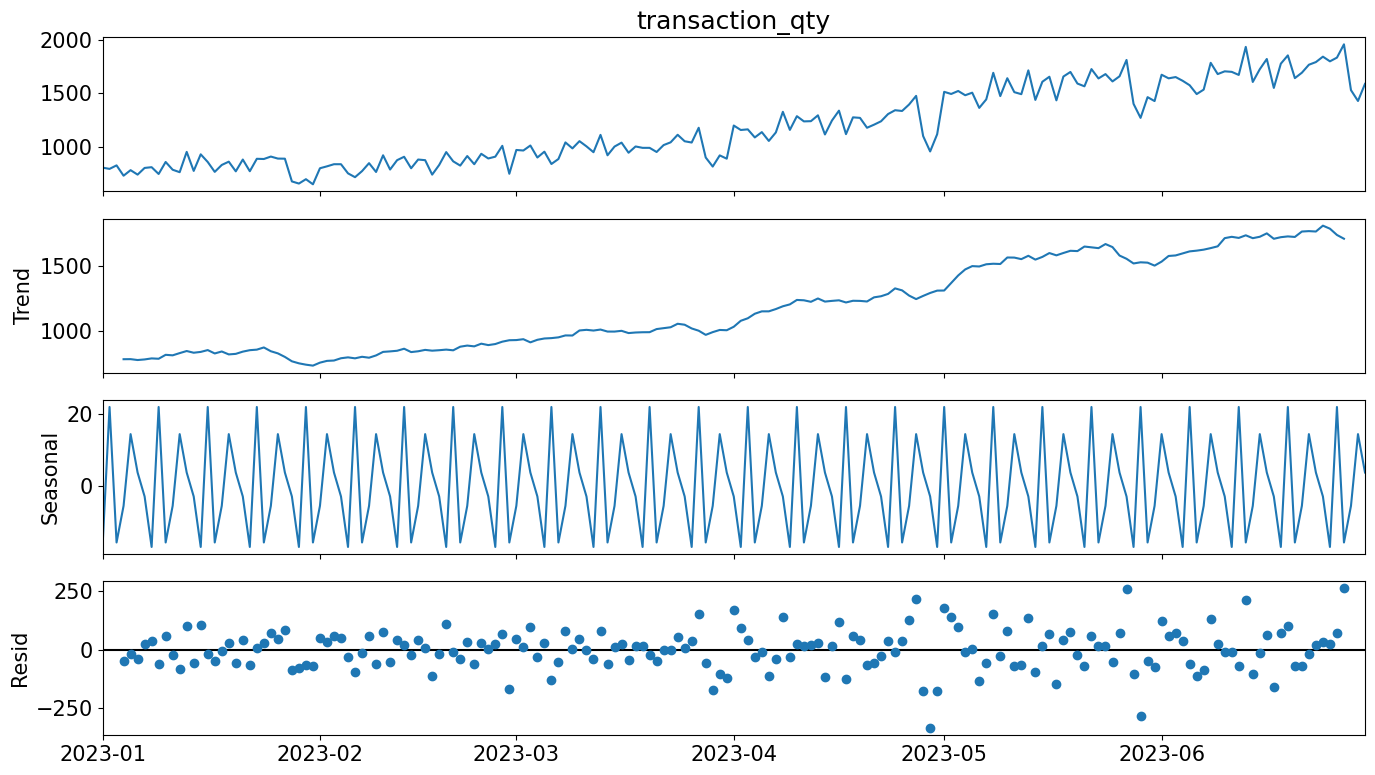

In [ ]:
# Decompose the time series
result = seasonal_decompose(df_perday["transaction_qty"], model="additive")
fig = result.plot()
plt.show()


In [ ]:
#Checking for stationarity using ADF test
result = adfuller(df_perday["transaction_qty"].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

if result[1] < 0.05:
    print("Time series is stationary")
else:
    print("Time series is non-stationary. Differencing might be needed.")


ADF Statistic: -0.12031808615858587
p-value: 0.9473767910109038
Time series is non-stationary. Differencing might be needed.


### SARIMA for Sales Quantity

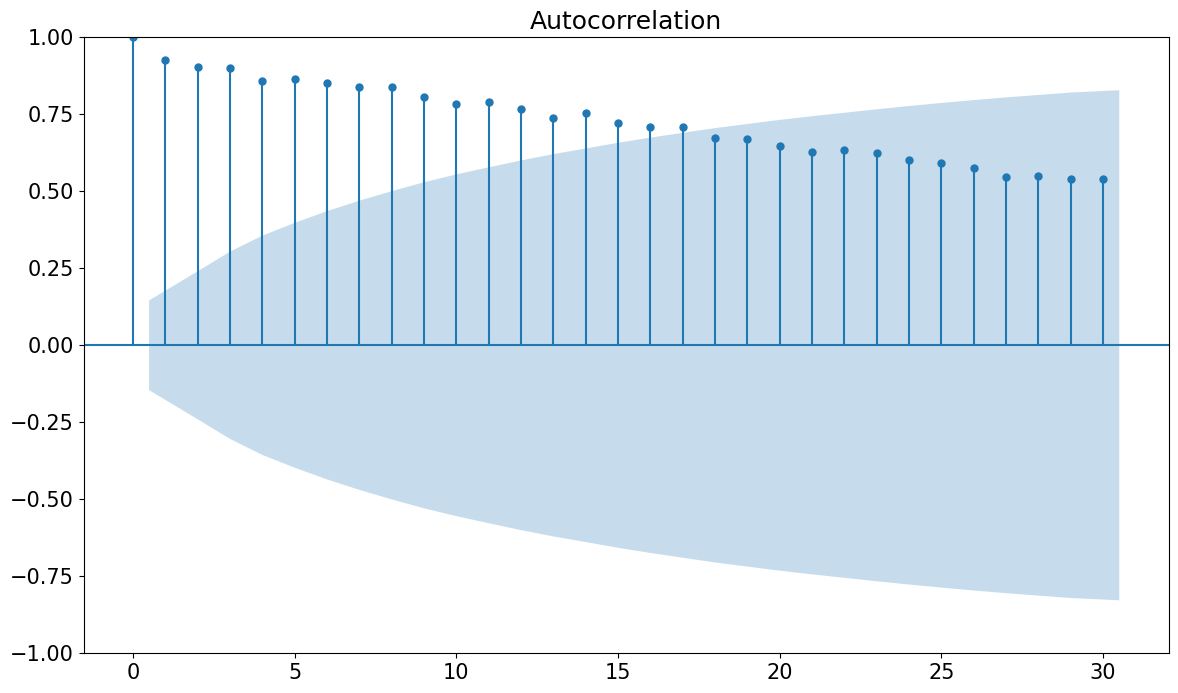

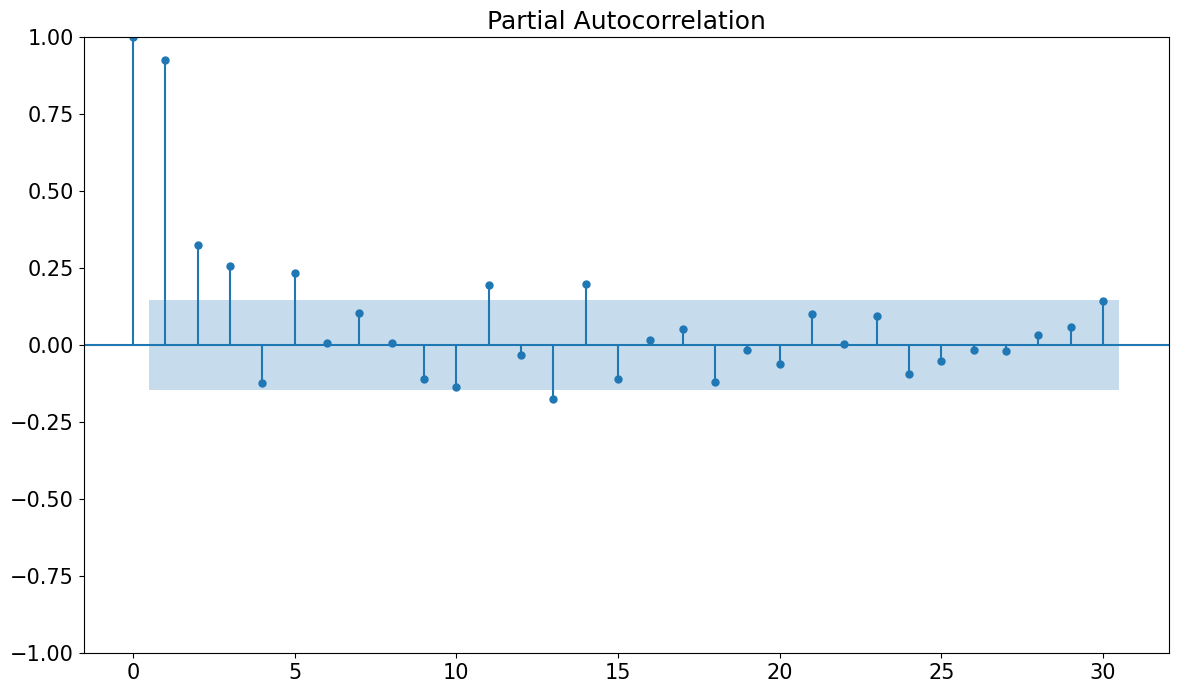

In [14]:
# Autocorrelation and Partial Autocorrelation Plots to determine (p, d, q) and (P, D, Q, m)
plot_acf(df_perday["transaction_qty"], lags=30)
plt.show()

plot_pacf(df_perday["transaction_qty"], lags=30)
plt.show()


In [15]:
# Set (p, d, q) and (P, D, Q, m) based on ACF/PACF
sarima_model = SARIMAX(df_perday["transaction_qty"], 
                       order=(3,1,1),  # Reduced AR term
                       seasonal_order=(1,1,1,7),  
                       enforce_stationarity=False, 
                       enforce_invertibility=False)


sarima_result = sarima_model.fit()
print(sarima_result.summary())


                                     SARIMAX Results                                     
Dep. Variable:                   transaction_qty   No. Observations:                  181
Model:             SARIMAX(3, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1011.042
Date:                           Wed, 26 Mar 2025   AIC                           2036.085
Time:                                   21:31:13   BIC                           2057.741
Sample:                               01-01-2023   HQIC                          2044.877
                                    - 06-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2796      0.119      2.355      0.019       0.047       0.512
ar.L2         -0.0459      0.090     -0.509

In [16]:
predictions = sarima_result.predict()

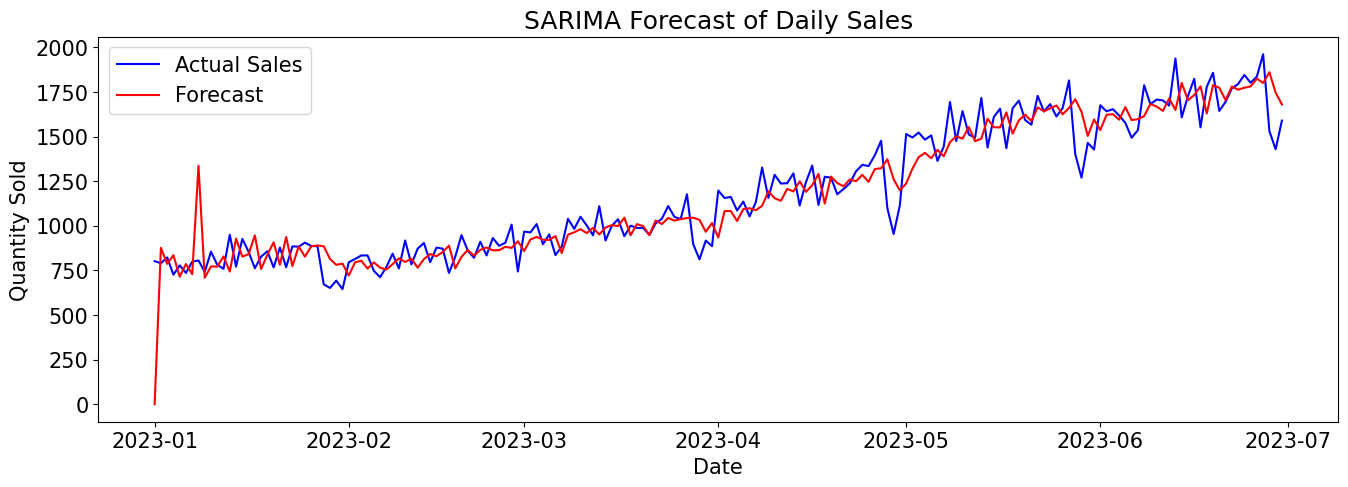

In [17]:
# Plot actual vs predicted
plt.figure(figsize=(16,5))
plt.plot(df_perday["transaction_qty"], label="Actual Sales", color="blue")
plt.plot(predictions, label="Forecast", color="red")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.title("SARIMA Forecast of Daily Sales")
plt.legend()
plt.show()

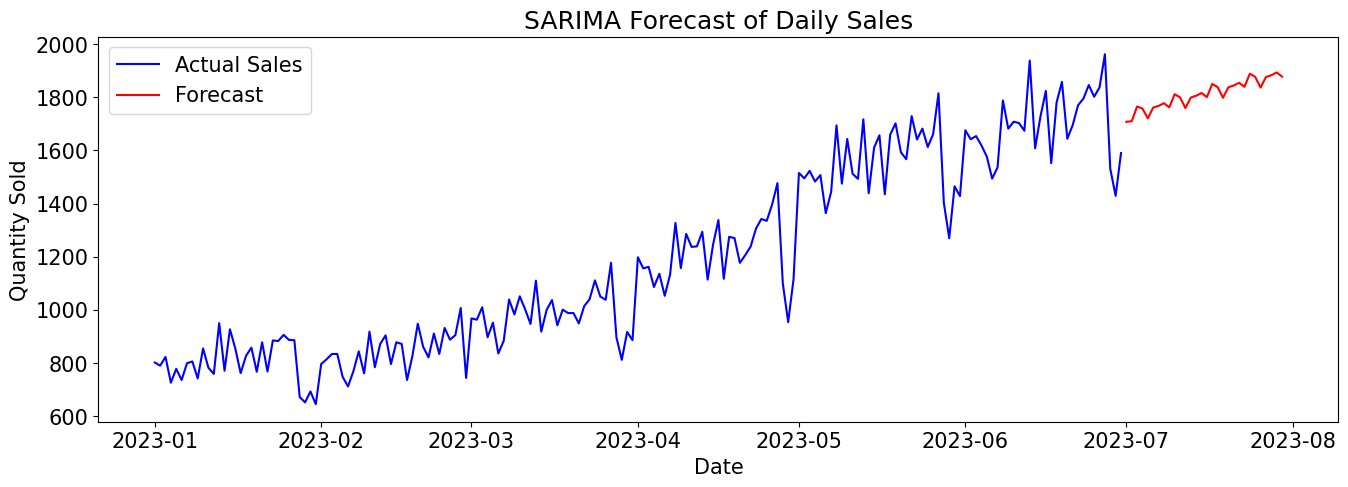

In [18]:
# Forecast for next 30 days
future_steps = 30
forecast = sarima_result.get_forecast(steps=future_steps)
forecast_index = pd.date_range(start=df_perday.index[-1], periods=future_steps+1, freq='D')[1:]
forecast_mean = forecast.predicted_mean

# Plot actual vs predicted
plt.figure(figsize=(16,5))
plt.plot(df_perday["transaction_qty"], label="Actual Sales", color="blue")
plt.plot(forecast_index, forecast_mean, label="Forecast", color="red")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.title("SARIMA Forecast of Daily Sales")
plt.legend()
plt.show()

### EDA for Sales Amount - SARIMA

In [19]:
# Filter the DataFrame to include only the Top 5 product categories
df_filtered = df[df["product_category"].isin(["Coffee", "Tea", "Bakery", "Drinking Chocolate", "Flavours"])]

In [20]:
# Aggregate total sales amount per day per category
df_grouped_sales = df_filtered.groupby(["transaction_date", "product_category"])["transaction_price"].sum().reset_index()

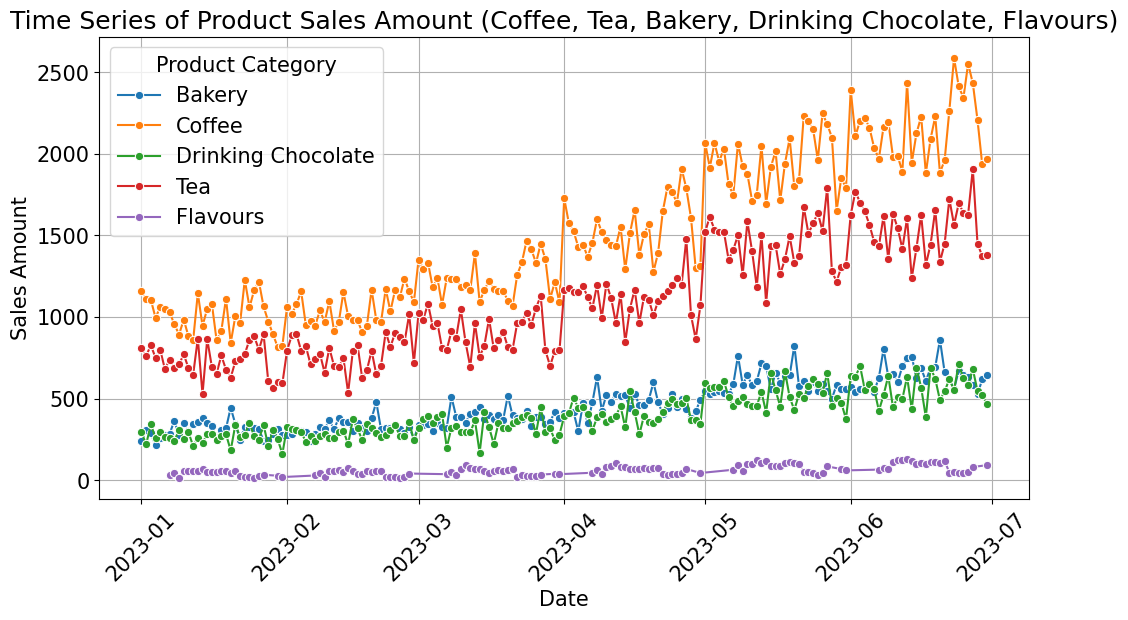

In [21]:
# Plot time series using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped_sales, x="transaction_date", y="transaction_price", hue="product_category", marker="o")

# Formatting
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("Time Series of Product Sales Amount (Coffee, Tea, Bakery, Drinking Chocolate, Flavours)")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.grid()
plt.show()

In [22]:
# Aggregate total quantity sold per day per category
df_daily_sales = df.groupby(["transaction_date"])["transaction_price"].sum().reset_index()

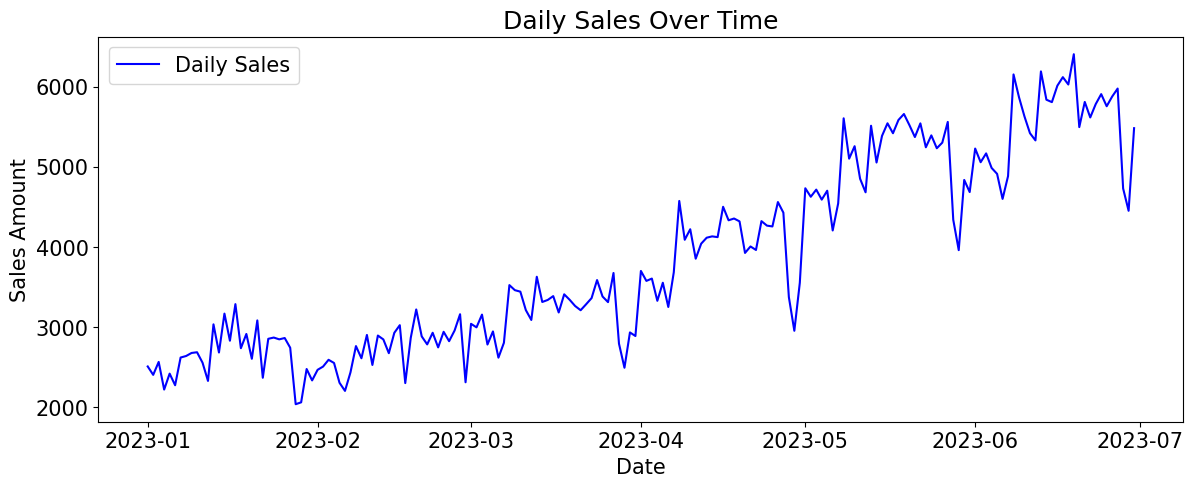

In [23]:
# Ensure the date column is in datetime format

df_daily_sales.set_index("transaction_date", inplace=True)
df_daily_sales = df_daily_sales.asfreq("D")  # Ensure daily frequency
df_daily_sales.sort_index(inplace=True)

# Plot the time series
plt.figure(figsize=(14,5))
plt.plot(df_daily_sales["transaction_price"], label="Daily Sales", color="blue")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("Daily Sales Over Time")
plt.legend()
plt.show()


In [38]:
df_daily_sales

,transaction_price
transaction_date,
2023-01-01,2508.20
2023-01-02,2403.35
2023-01-03,2565.00
2023-01-04,2220.10
2023-01-05,2418.85
...,...
2023-06-26,5875.90
2023-06-27,5975.65
2023-06-28,4728.90


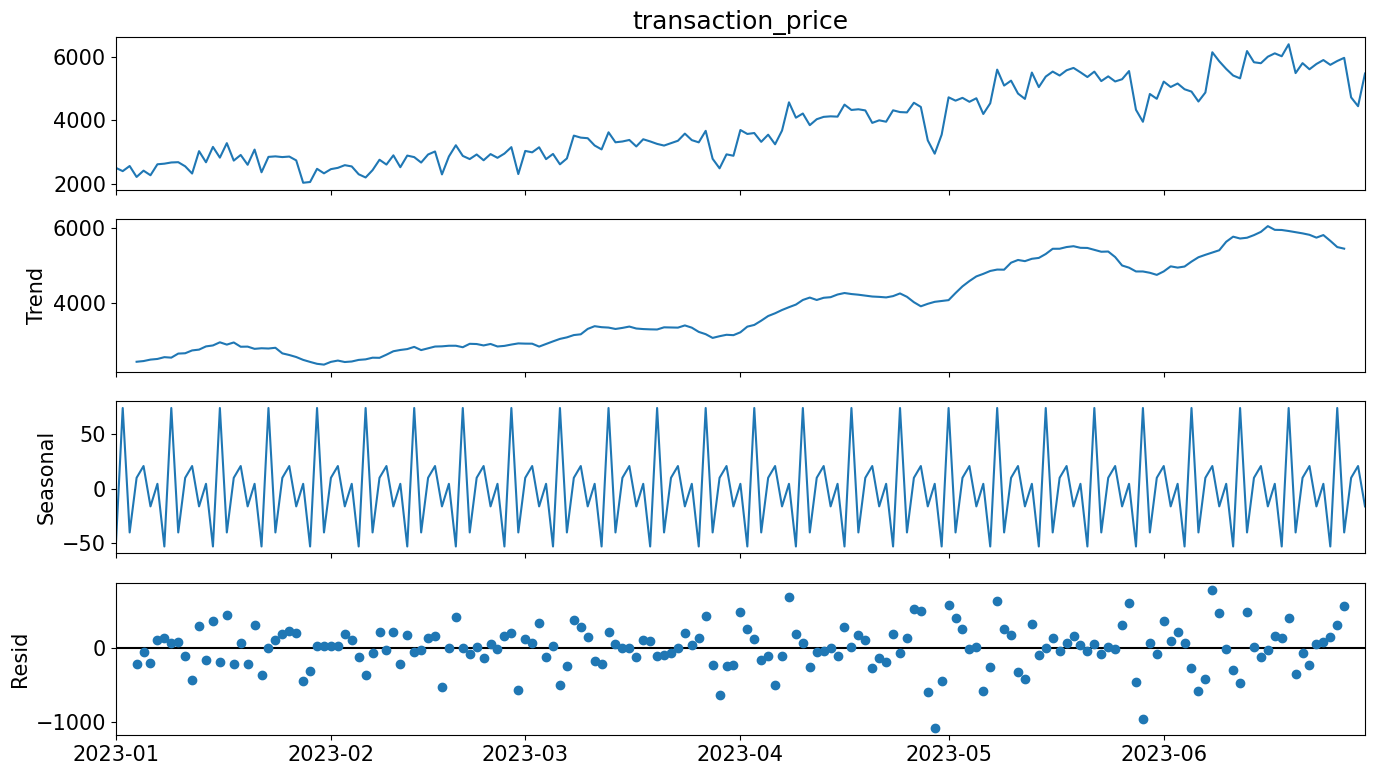

In [24]:
# Decompose the time series to understand its components
result = seasonal_decompose(df_daily_sales["transaction_price"], model="additive")
fig = result.plot()
plt.show()


In [25]:
# Check for stationarity using ADF test
result_adf_sales = adfuller(df_daily_sales["transaction_price"].dropna())
print(f"ADF Statistic: {result_adf_sales[0]}")
print(f"p-value: {result_adf_sales[1]}")

if result_adf_sales[1] < 0.05:
    print("Time series is stationary")
else:
    print("Time series is non-stationary. Differencing might be needed.")


ADF Statistic: -0.7085692033124137
p-value: 0.8445174174763055
Time series is non-stationary. Differencing might be needed.


### SARIMA for Sales Amount

### Using Statsmodel SARIMA 

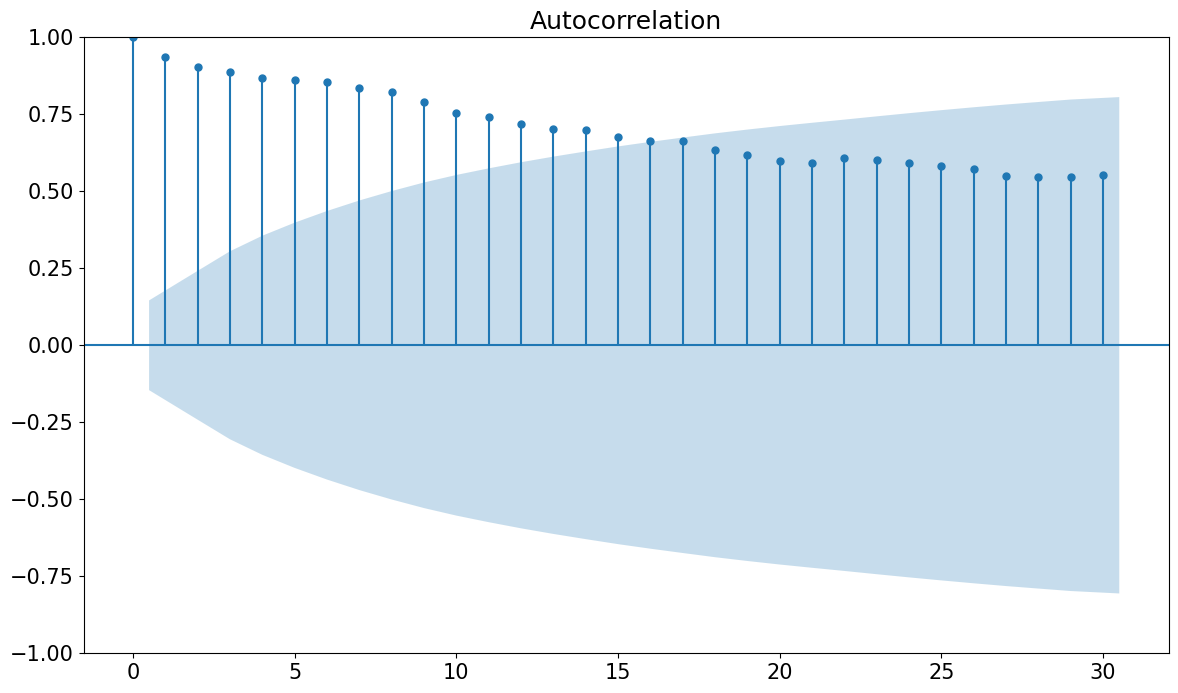

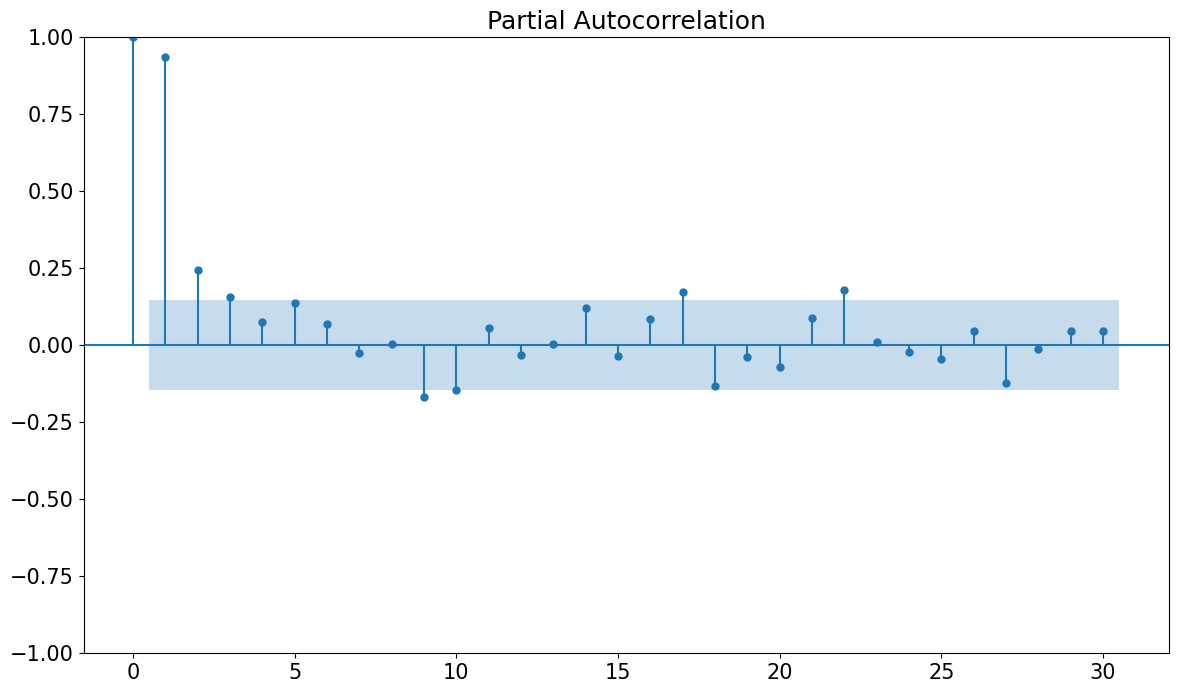

In [26]:
# Autocorrelation and Partial Autocorrelation Plots to determine (p, d, q) and (P, D, Q, m)
plot_acf(df_daily_sales["transaction_price"], lags=30)
plt.show()

plot_pacf(df_daily_sales["transaction_price"], lags=30)
plt.show()

In [27]:
# Set (p, d, q) and (P, D, Q, m) based on ACF/PACF
sarima_model_sales = SARIMAX(df_daily_sales["transaction_price"], 
                       order=(1,1,1),  
                       seasonal_order=(1,1,1,7),  
                       enforce_stationarity=False, 
                       enforce_invertibility=False)


sarima_result_sales = sarima_model_sales.fit()
print(sarima_result_sales.summary())


                                     SARIMAX Results                                     
Dep. Variable:                 transaction_price   No. Observations:                  181
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -1210.115
Date:                           Wed, 26 Mar 2025   AIC                           2430.230
Time:                                   21:31:15   BIC                           2445.729
Sample:                               01-01-2023   HQIC                          2436.522
                                    - 06-30-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4243      0.110      3.844      0.000       0.208       0.641
ma.L1         -0.8542      0.077    -11.048

In [28]:
predictions_sales = sarima_result_sales.predict()

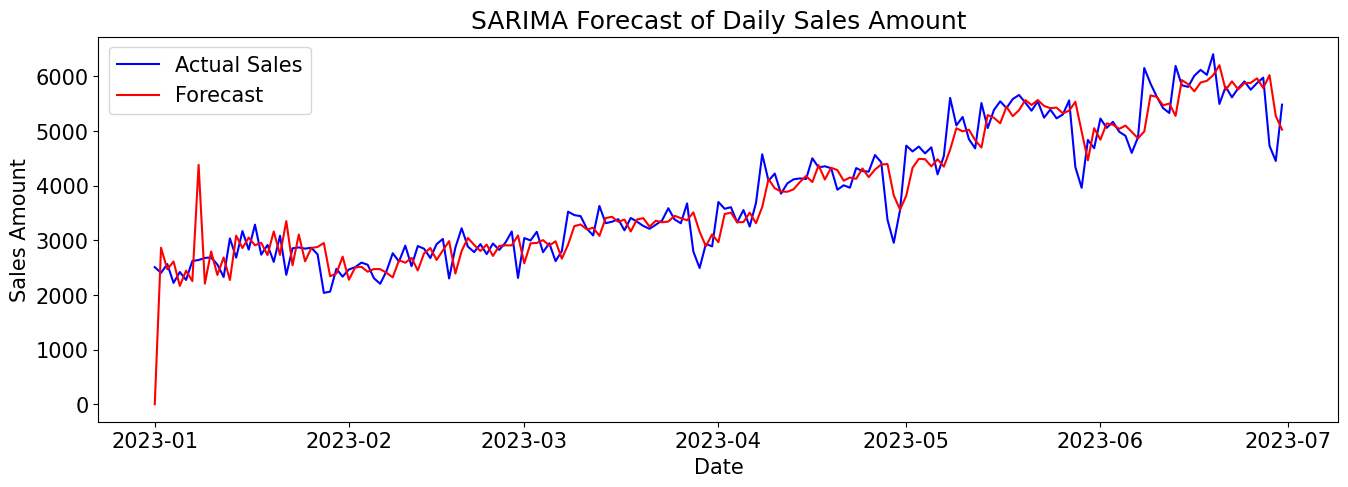

In [29]:
# Plot actual vs predicted
plt.figure(figsize=(16,5))
plt.plot(df_daily_sales["transaction_price"], label="Actual Sales", color="blue")
plt.plot(predictions_sales, label="Forecast", color="red")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("SARIMA Forecast of Daily Sales Amount")
plt.legend()
plt.show()

In [30]:
import statsmodels.api as sm

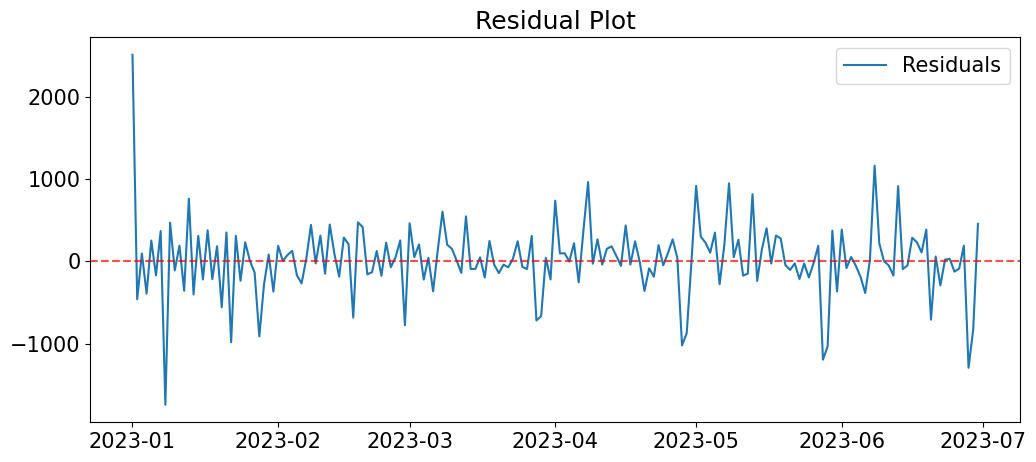

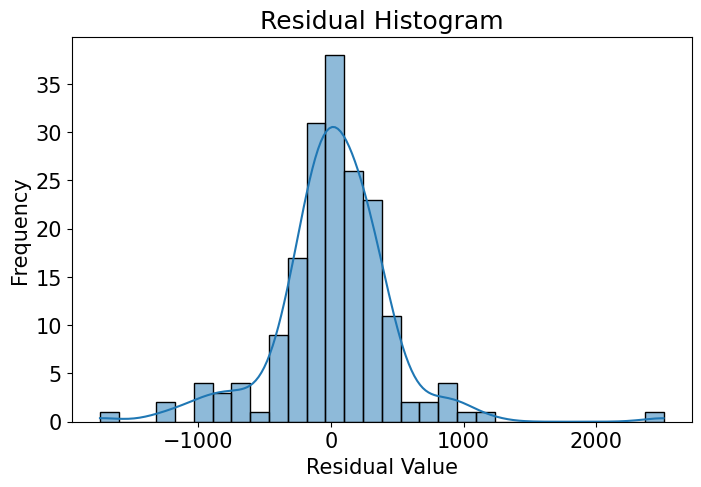

In [31]:
# Get residuals
residuals = sarima_result_sales.resid

# Plot residual time series
plt.figure(figsize=(12,5))
plt.plot(residuals, label="Residuals")
plt.axhline(0, linestyle='--', color='red', alpha=0.7)
plt.title("Residual Plot")
plt.legend()
plt.show()

# Histogram of residuals
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Histogram")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()

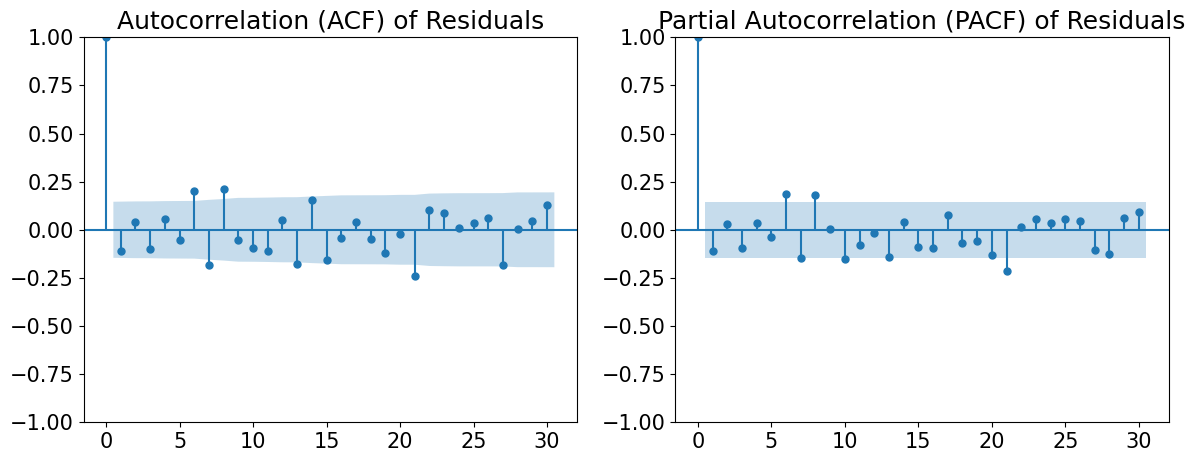

In [32]:
#Autocorrelation & Partial Autocorrelation of Residuals

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sm.graphics.tsa.plot_acf(residuals, ax=axes[0], lags=30)
axes[0].set_title("Autocorrelation (ACF) of Residuals")

sm.graphics.tsa.plot_pacf(residuals, ax=axes[1], lags=30)
axes[1].set_title("Partial Autocorrelation (PACF) of Residuals")

plt.show()


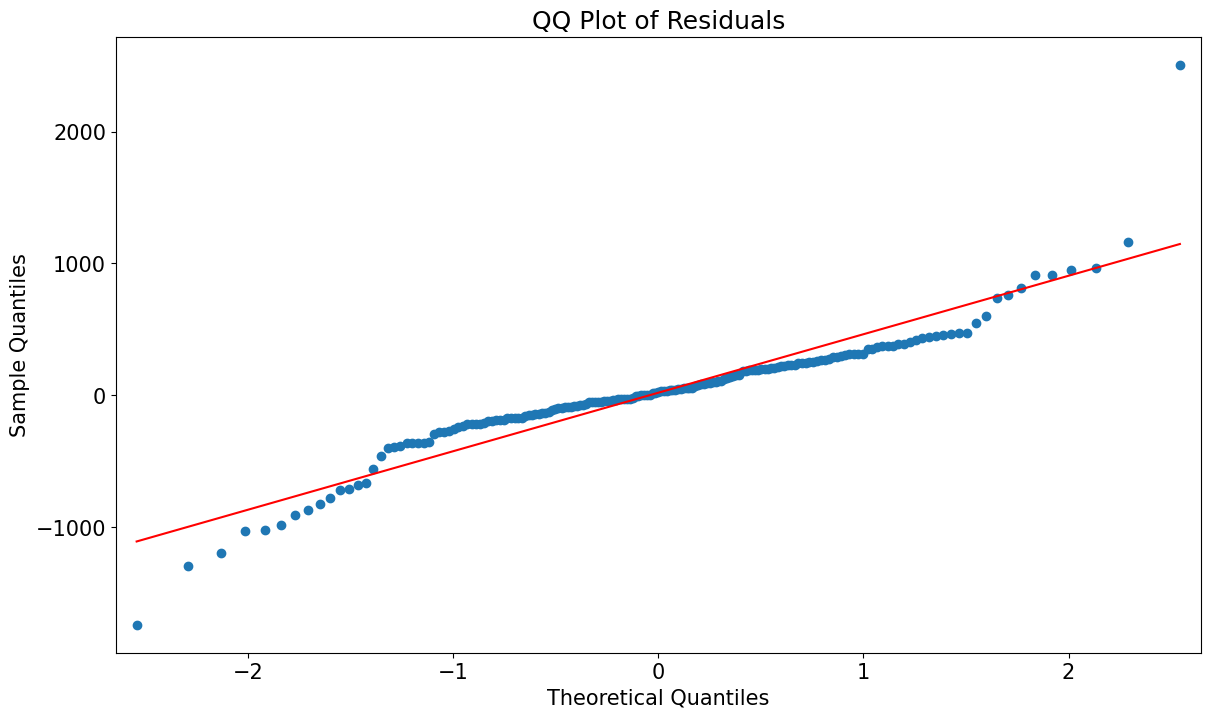

In [33]:
# QQ Plot of Residuals
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.show()


### Using AutoArima Best Parameters

In [34]:
# SECOND TRIAL USING AUTO ARIMA BEST PARAMETERS 
# Set (p, d, q) and (P, D, Q, m) based on ACF/PACF
sarima_model_sales_auto = SARIMAX(df_daily_sales["transaction_price"], 
                       order=(1,1,1),  
                       seasonal_order=(1,0,2,7),  
                       enforce_stationarity=False, 
                       enforce_invertibility=False)


sarima_result_sales_auto = sarima_model_sales_auto.fit()
print(sarima_result_sales_auto.summary())


                                       SARIMAX Results                                        
Dep. Variable:                      transaction_price   No. Observations:                  181
Model:             SARIMAX(1, 1, 1)x(1, 0, [1, 2], 7)   Log Likelihood               -1196.390
Date:                                Wed, 26 Mar 2025   AIC                           2404.780
Time:                                        21:31:25   BIC                           2423.379
Sample:                                    01-01-2023   HQIC                          2412.330
                                         - 06-30-2023                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3867      0.152      2.539      0.011       0.088       0.685
ma.

In [35]:
predictions_sales_auto = sarima_result_sales_auto.predict()

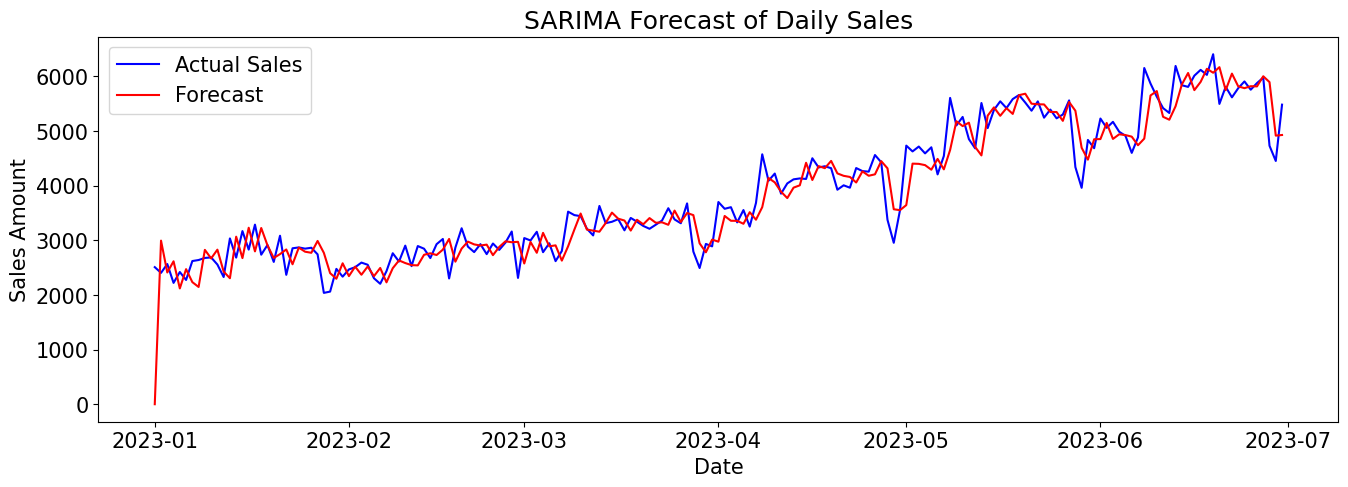

In [36]:
# Plot actual vs predicted
plt.figure(figsize=(16,5))
plt.plot(df_daily_sales["transaction_price"], label="Actual Sales", color="blue")
plt.plot(predictions_sales_auto, label="Forecast", color="red")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.title("SARIMA Forecast of Daily Sales")
plt.legend()
plt.show()

In [37]:
# Calculate metrics
mse = mean_squared_error(df_daily_sales["transaction_price"], predictions_sales_auto)
mae = mean_absolute_error(df_daily_sales["transaction_price"], predictions_sales_auto)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(df_daily_sales["transaction_price"], predictions_sales_auto)  # R-squared
mape = np.mean(np.abs((df_daily_sales["transaction_price"] - predictions_sales_auto) / df_daily_sales["transaction_price"])) * 100  # MAPE

# Print the metrics
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')


Mean Squared Error (MSE): 162998.70
Mean Absolute Error (MAE): 269.97
Root Mean Squared Error (RMSE): 403.73
R-squared (R²): 0.88
Mean Absolute Percentage Error (MAPE): 7.78%


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming df_daily_sales has 'transaction_date' as DateTime index
df_daily_sales = df_daily_sales.sort_index()  # Ensure it's sorted

# **Step 1: Train-Test Split**
test_size = 30  # Last 30 days for testing
train = df_daily_sales.iloc[:-test_size]
test = df_daily_sales.iloc[-test_size:]

# **Step 2: Fit SARIMAX Model**
sarimax_model = SARIMAX(
    train["transaction_price"],  # Target variable
    order=(1, 1, 1),  # ARIMA (p, d, q) order - Tune this!
    seasonal_order=(1, 1, 1, 7),  # SARIMA (P, D, Q, s) - Weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit()

# **Step 3: Forecast on Test Set**
predictions = sarimax_fit.forecast(steps=test_size)

# **Step 4: Compare Predictions with Actuals**
results = pd.DataFrame({"Actual": test["transaction_price"], "Predicted": predictions})
print(sarimax_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                 transaction_price   No. Observations:                  151
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -993.145
Date:                           Wed, 26 Mar 2025   AIC                           1996.290
Time:                                   21:41:55   BIC                           2010.779
Sample:                               01-01-2023   HQIC                          2002.177
                                    - 05-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3364      0.205      1.640      0.101      -0.066       0.739
ma.L1         -0.7245      0.151     -4.782

In [51]:
predictions_test = sarimax_fit.predict(start=test.index[0], end=test.index[-1])

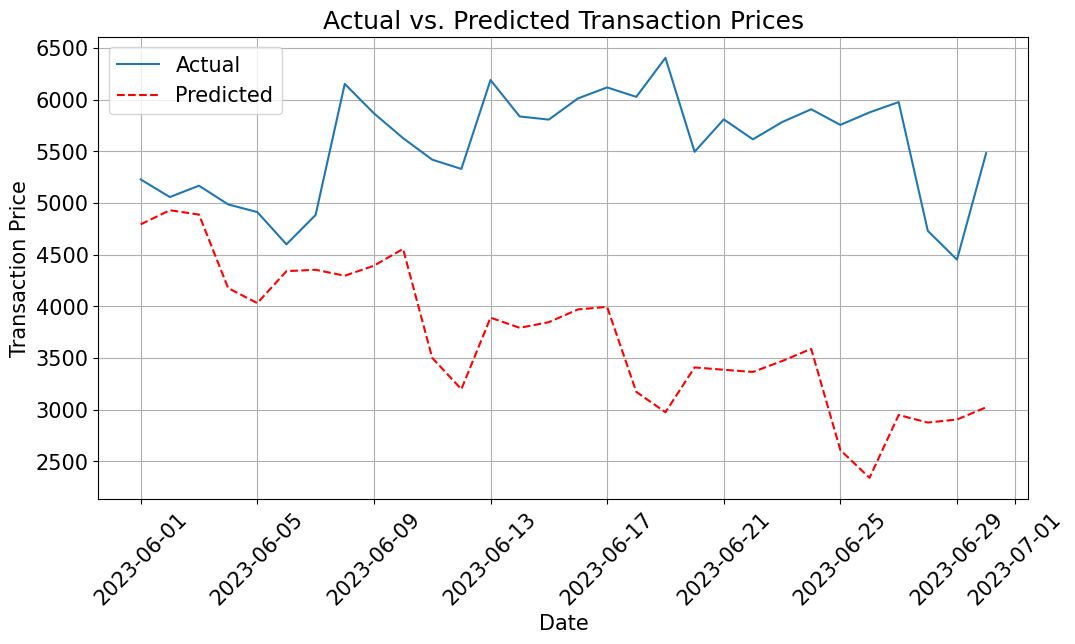

In [ ]:
# Plot Actual vs. Predicted Values**
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["transaction_price"], label="Actual", linestyle="-")
plt.plot(test.index, predictions_test, label="Predicted", linestyle="--", color="red")
plt.xlabel("Date")
plt.ylabel("Transaction Price")
plt.title("Actual vs. Predicted Transaction Prices")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [54]:
# Save predictions to CSV
predictions_test.to_csv("sarimax_predictions.csv", index=True)


In [48]:
# **Step 5: Evaluate the Model**
mse = mean_squared_error(test["transaction_price"], predictions)
mae = mean_absolute_error(test["transaction_price"], predictions)
rmse = np.sqrt(mse)  # Root Mean Squared Error
r2 = r2_score(test["transaction_price"], predictions)  # R-squared
mape = np.mean(np.abs((test["transaction_price"] - predictions) / test["transaction_price"])) * 100  # MAPE

# Print the metrics
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')

Mean Squared Error (MSE): 4283068.63
Mean Absolute Error (MAE): 1850.23
Root Mean Squared Error (RMSE): 2069.56
R-squared (R²): -15.85
Mean Absolute Percentage Error (MAPE): 32.53%


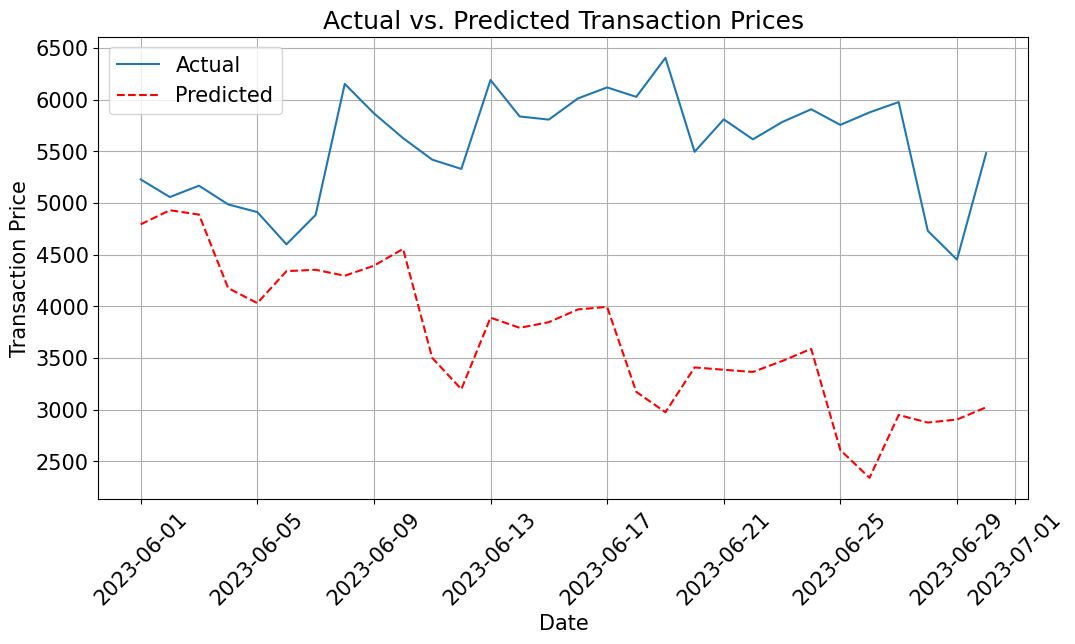

In [50]:
# **Step 5: Plot Actual vs. Predicted Values**
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["transaction_price"], label="Actual", linestyle="-")
plt.plot(test.index, predictions, label="Predicted", linestyle="--", color="red")
plt.xlabel("Date")
plt.ylabel("Transaction Price")
plt.title("Actual vs. Predicted Transaction Prices")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Future Predictions

In [1]:
# **Step 6: Forecast Next 7 Days**
future_steps = 7  # Predict the next 7 days
future_dates = pd.date_range(start=test.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq="D")

# Generate forecast
future_predictions = sarimax_fit.forecast(steps=future_steps)

# Convert to DataFrame
future_results = pd.DataFrame({
    "Date": future_dates, 
    "Predicted_Transaction_Price": future_predictions
})

# **Step 7: Plot Future Forecast**
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["transaction_price"], label="Actual", linestyle="-")
plt.plot(test.index, predictions_test, label="Predicted (Test Set)", linestyle="--", color="red")
plt.plot(future_dates, future_predictions, label="Future Forecast (Next 7 Days)", linestyle="--", color="green")

plt.xlabel("Date")
plt.ylabel("Transaction Price")
plt.title("Actual vs. Predicted vs. Future Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# **Step 8: Save Future Predictions to CSV**
future_results.to_csv("future_sarimax.csv", index=False)
print("Future predictions saved as 'future_sarimax.csv'.")


NameError: name 'pd' is not defined